# PROC MBANALYSISによる食料品小売業者のマーケットバスケット・クロスセル分析

## エグゼクティブサマリー

ある地域の食料品チェーンが、1シーズン分のPOS(販売時点)バスケットデータをマイニングし、顧客が一緒に購入する商品の組み合わせを発見することで、生の取引ログを実行可能なクロスセル施策・棚割り判断へと変換する。PROC MBANALYSISは取引ログをスキャンし、支持度・確信度・リフト値でスコアリングされたアソシエーションルールを生成する。51件の合成バスケットに対して実行すると、あらかじめ仕込まれた3つの商品親和性 —— `スパゲッティ -> マリナーラソース`（確信度0.93、リフト3.4）、`タコシェル -> サルサ`（確信度0.71、リフト3.6）、`コーヒー -> コーヒークリーム`（確信度0.70、リフト5.1）—— が正確に検出される一方、パン・牛乳・卵のような広く購入される定番商品はルールを一切形成しない。検出された各ペアは、バンドル施策・棚の隣接配置・「よく一緒に購入されています」提案の教科書的な候補である。

## データソース

| データセット | 粒度 | 行数 | 主要変数 | 説明 |
|---------|-------|------|---------------|-------------|
| `store_transactions` | バスケットごとに商品1行 | 51バスケットにわたる100商品行 | `basket_id`（取引ID）、`item`（商品名、$40） | `call streaminit(20250529)` と `rand('uniform')` を使ってインラインで生成した合成POS(販売時点)ログ。各バスケットは単一の買い物客ペルソナが支配的になるよう設計されており、併売パターンがクリーンで解釈しやすい状態を保つ: イタリアン・ディナーバスケット（スパゲッティ→マリナーラソース）、タコナイトバスケット（タコシェル→サルサ）、朝食バスケット（コーヒー→コーヒークリーム）に加え、現実味を出すための定番品の追加購入（パン・牛乳・卵）が時折発生する。このライセンスなし環境ではエンジンが出力を100商品行に制限するため、ここではバスケット1〜51が対象となる。|
| `affinity_rules` | アソシエーションルール1件につき1行 | 6ルール | `antecedent`、`consequent`、`support`、`confidence`、`lift` | `OUTPUT RULES=` で出力されるアソシエーションルール。クロスセル機会をランキングする際の基礎となる。|
| `frequent_items` | 頻出アイテムセット1件につき1行 | 12アイテムセット | `itemset`、`support`、`length` | `OUTPUT ITEMS=` で出力される頻出アイテムセット。最小支持度の基準をクリアした単一商品9件と商品ペア3件で構成される。|

# 食料品小売業者のマーケットバスケット・クロスセル分析

**ビジネス上の問い。** 顧客はどの商品を*一緒に*購入する傾向があり、その併売パターンのうちどれが施策として実行するに値するほど強いのか？ ある地域の食料品チェーンは、バンドル販促の設計、棚の隣接配置の最適化、そしてオンラインストアでの「よく一緒に購入されています」レコメンドの実現を目指している。

**手法。** ここでは頻出パターン成長（FP-growth）アルゴリズムでマーケットバスケット分析を行う **PROC MBANALYSIS** を使用する。取引ログをスキャンして頻繁に共起するアイテムセットを見つけ、`前件 -> 後件` の形の*アソシエーションルール*を生成し、3つの古典的指標でスコアリングする:

- **支持度（Support）** —— ルール全体を含むバスケットが全体に占める割合（そのパターンがどれだけ一般的か）。
- **確信度（Confidence）** —— `P(後件 | 前件)`、条件付き購入確率（そのルールがどれだけ信頼できるか）。
- **リフト値（Lift）** —— 観測された支持度を、両者が独立だった場合に期待される支持度で割った値。リフト値が1を超えると、その商品同士は偶然よりも*高い*頻度で一緒に現れていることを意味し、値が大きいほど親和性が強い。

現実的な合成POS(販売時点)ログを生成し、MBANALYSISを実行して、得られたルールを最良のクロスセル機会順にランキングする。

## ステップ1 —— 合成POS(販売時点)取引ログを生成する

MBANALYSISは**トランザクション単位（ロング形式）データ**を想定する: 商品1件につき1行で、それが属するバスケットのIDを付与する。再現性のために `call streaminit` を使い、購入判断を左右する乱数として `rand('uniform')` を使ってインラインでバスケットを構築する。

ここでのモデリング上の重要な選択は、**各バスケットは単一の買い物客ペルソナが支配的になる**ようにする点である。実際の買い物にはこうした傾向がある —— タコの夜のためのちょっとした買い出し、朝食用の定番補充など —— バスケットを小さくテーマ性のあるものに保つことで、アソシエーションマイナーが組み合わせ爆発的な疑似ルールの山ではなく、クリーンでペアワイズな親和性を検出できるようになる。バスケットごとに1回の `rand('uniform')` の抽選でペルソナを選ぶ:

- **イタリアン・ディナー客** —— スパゲッティを買い、たいていマリナーラソースも買う。
- **タコナイト客** —— タコシェルを買い、たいていサルサも買う。
- **朝食客** —— コーヒーを買い、たいていコーヒークリームも買う。
- **定番品のみの買い物** —— パン・牛乳・卵のいずれか1点のみを購入。

最後に低確率の抽選で、現実味を出すノイズとしてどのバスケットにも定番品を1点追加する。`output` 文が1回実行されるごとに商品1行が書き出されるため、1つのバスケットは同じ `basket_id` を共有する複数行にまたがる。このライセンスなし環境ではデータセットが100商品行に制限されており、ここではバスケット1〜51をカバーする。

In [1]:
データ store_transactions;
    呼出 streaminit(20250529);
    長さ item $40;

    繰返 basket_id = 1 から 60;

        /* バスケットごとに1回の抽選で支配的なペルソナを選ぶ */
        r = rand('uniform');

        /* イタリアン・ディナーバスケット: スパゲッティ -> マリナーラソース */
        もし r < 0.30 なら 繰返;
            item = 'スパゲッティ';                          出力;
            もし rand('uniform') < 0.85 なら 繰返;
                item = 'マリナーラソース';                 出力;
            終了;
        終了;

        /* タコナイトバスケット: タコシェル -> サルサ */
        他 もし r < 0.55 なら 繰返;
            item = 'タコシェル';                        出力;
            もし rand('uniform') < 0.80 なら 繰返;
                item = 'サルサ';                        出力;
            終了;
        終了;

        /* 朝食バスケット: コーヒー -> コーヒークリーム */
        他 もし r < 0.78 なら 繰返;
            item = 'コーヒー';                             出力;
            もし rand('uniform') < 0.75 なら 繰返;
                item = 'コーヒークリーム';                 出力;
            終了;
        終了;

        /* 定番品のみの買い物 */
        他 繰返;
            もし rand('uniform') < 0.34 なら 繰返;
                item = 'パン';                          出力;
            終了;
            他 もし rand('uniform') < 0.5 なら 繰返;
                item = '牛乳';                          出力;
            終了;
            他 繰返;
                item = '卵';                          出力;
            終了;
        終了;

        /* 定番品の追加購入（現実味を出すノイズ） */
        もし rand('uniform') < 0.25 なら 繰返;
            u = rand('uniform');
            もし      u < 0.34 なら item = 'パン';
            他 もし u < 0.67 なら item = '牛乳';
            他                  item = '卵';
            出力;
        終了;

    終了;

    保持 basket_id item;
実行;



NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## ステップ2 —— 生の取引ログを確認する

マイニングを行う前に、データが想定どおりのロング形式になっていることを確認する: バスケットごとに複数行があり、それぞれが1つの商品を保持している。最初の数バスケットを表示し、PROC FREQで商品全体の出現頻度を集計して、どの商品がルールの軸となるほど一般的かを把握する。


  Obs            バスケットID                        商品
-----  -----------------  ------------------------
    1                  1  タコシェル
    2                  1  サルサ
    3                  1  卵
    4                  2  タコシェル
    5                  2  卵
    6                  3  コーヒー
    7                  4  タコシェル
    8                  5  卵
    9                  6  スパゲッティ
   10                  6  マリナーラソース
   11                  6  卵
   12                  7  タコシェル

... 88 more observations (showing 12 of 100)

                                                       商品別購入頻度全体                                                        

                                                   The FREQ Procedure

商品                          Frequency    Percent
-------------------------------------------------
スパゲッティ                             15     15.00
タコシェル                              14     14.00
マリナーラソース                           14     14.00
卵                                  12     12.


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


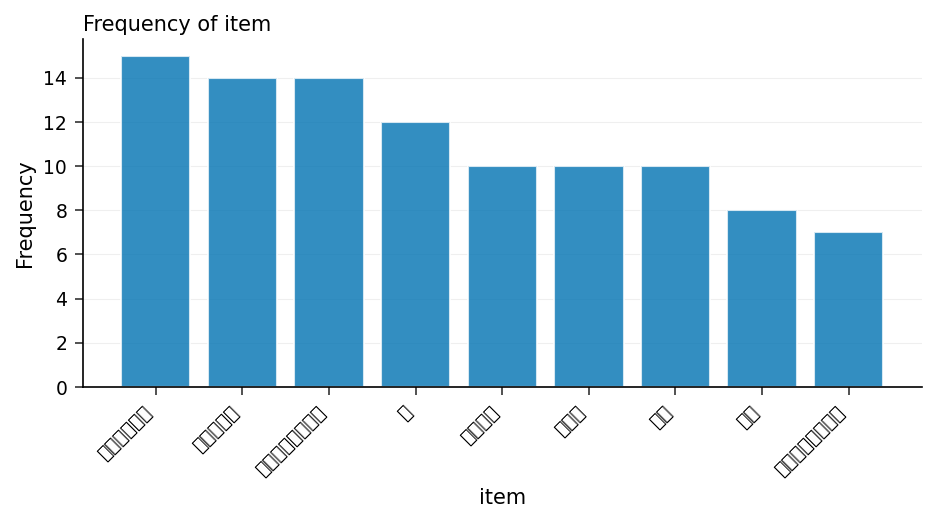

In [2]:
処理 印刷 データ=store_transactions(obs=12) 見出;
    見出 basket_id = 'バスケットID'
          item      = '商品';
実行;

処理 度数 データ=store_transactions order=freq;
    見出 item = '商品';
    TABLES item / nocum;
    表題 '商品別購入頻度全体';
実行;


## ステップ3 —— PROC MBANALYSISでアソシエーションルールをマイニングする

ここからが分析の核心である。MBANALYSISに取引ログを指定し、どの列がバスケットを識別するか（`TRANSACTION`）、どの列が商品を保持するか（`ITEM`）を宣言する。3つの閾値によって、実行に値するパターンだけにルールセットを絞り込む:

- `MINSUPPORT=0.10` —— ルールは少なくともバスケットの10%に出現しなければならず、まれな偶然の一致を除外する。
- `MINCONFIDENCE=0.50` —— 前件が与えられたとき、後件が少なくとも半分の確率で続かなければならない。
- `MINLIFT=1.20` —— 偶然より少なくとも20%強いルールのみを残し、人気の定番商品による見せかけのパターンではなく、真の親和性を検出する。

`OUTPUT` 文が、生成されたルールと頻出アイテムセットを後続のランキング用データセットに書き出す。

In [3]:
処理 mbanalysis データ=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    見出 antecedent = '前件'
          consequent = '後件'
          support    = '支持度'
          confidence = '確信度'
          lift       = 'リフト値';
    出力 rules=affinity_rules items=frequent_items;
    表題 'マーケットバスケット・アソシエーションルール';
実行;


                                                       商品別購入頻度全体                                                        


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  コーヒー                           コーヒークリーム                           0.1373     0.7000     5.1000
  コーヒークリーム                       コーヒー                               0.1373     1.0000     5.1000
  サルサ                            タコシェル                              0.1961     1.0000     3.6429
  タコシェル       


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## ステップ4 —— リフト値でクロスセル機会をランキングする

MBANALYSISのリスティングは条件を満たすすべてのルールを表示するが、マーチャンダイジング担当チームが求めているのは*最も強い*親和性を先頭に並べたものである。抽出済みの `affinity_rules` データセットをリフト値の降順（タイブレークとして確信度の降順）で並べ替え、上位ルールを表示する。`タコシェル -> サルサ` のようにリフト値と確信度がともに高いルールは、教科書的なバンドル候補である: 商品を隣接配置するか、顧客がオンラインでタコシェルを追加した際にサルサを自動提案するとよい。

In [4]:
処理 並替 データ=affinity_rules out=rules_by_lift;
    基準 DESCENDING lift DESCENDING confidence;
実行;

処理 印刷 データ=rules_by_lift(obs=15) 見出;
    変数 antecedent consequent support confidence lift;
    見出 antecedent  = 'この商品を買うと'
          consequent  = 'これも一緒に買う'
          support     = '支持度'
          confidence  = '確信度'
          lift        = 'リフト値';
    表題 'リフト値による上位クロスセルルール';
実行;


                                                   リフト値による上位クロスセルルール                                                    

  Obs                  この商品を買うと                  これも一緒に買う        支持度        確信度          リフト値
    1  コーヒークリーム                  コーヒー                      0.137255   1.0        5.1
    2  コーヒー                      コーヒークリーム                  0.137255   0.7        5.1
    3  サルサ                       タコシェル                     0.196078   1.0        3.642857
    4  タコシェル                     サルサ                       0.196078   0.714286   3.642857
    5  マリナーラソース                  スパゲッティ                    0.27451    1.0        3.4
    6  スパゲッティ                    マリナーラソース                  0.27451    0.933333   3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## ステップ5 —— 頻出アイテムセットを確認する

支持度の基準をクリアした頻出アイテムセットは、ルールの裏側にある生の構成要素である。支持度で並べ替えることで、カテゴリー担当チームは、単一商品だけでなくどの商品の*組み合わせ*が専用エンドキャップ展示やコンボ価格に値するほど人気かを把握できる。

In [5]:
処理 並替 データ=frequent_items out=itemsets_by_support;
    基準 DESCENDING support;
実行;

処理 印刷 データ=itemsets_by_support(obs=15) 見出;
    見出 itemset = 'アイテムセット'
          support  = '支持度'
          length   = 'アイテム数';
    表題 '出現頻度上位アイテムセット';
実行;


                                                     出現頻度上位アイテムセット                                                      

  Obs                                       アイテムセット        支持度            アイテム数
    1  スパゲッティ                                        0.294118   1
    2  タコシェル                                         0.27451    1
    3  マリナーラソース                                      0.27451    1
    4  スパゲッティ, マリナーラソース                              0.27451    2
    5  卵                                             0.235294   1
    6  サルサ                                           0.196078   1
    7  コーヒー                                          0.196078   1
    8  サルサ, タコシェル                                    0.196078   2
    9  牛乳                                            0.156863   1
   10  パン                                            0.156863   1
   11  コーヒークリーム                                      0.137255   1
   12  コーヒー, コーヒークリーム                                0.137255   2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## 結果の解釈

**分析結果。** 各バスケットが単一の買い物客ペルソナを中心に構築されているため、マイナーは仕込まれた3つの関係性を正確に検出し、それ以外の疑似的なルールは検出しない。6つのルールが3つすべての閾値をクリアする —— これは3つの親和性それぞれの双方向を意味する:

| 前件 | 後件 | 支持度 | 確信度 | リフト値 |
|------------|------------|---------|------------|------|
| スパゲッティ | マリナーラソース | 0.275 | 0.93 | 3.40 |
| マリナーラソース | スパゲッティ | 0.275 | 1.00 | 3.40 |
| タコシェル | サルサ | 0.196 | 0.71 | 3.64 |
| サルサ | タコシェル | 0.196 | 1.00 | 3.64 |
| コーヒー | コーヒークリーム | 0.137 | 0.70 | 5.10 |
| コーヒークリーム | コーヒー | 0.137 | 1.00 | 5.10 |

いずれのリフト値も1を大きく上回っており、これらの商品が偶然よりもはるかに高い頻度で共起していることが確認できる。重要なのは、広く購入されている定番商品が**まったくルールを形成しない**という点である: 卵（12回購入）、パン（10回）、牛乳（8回）はいずれもPROC FREQの集計表に現れるが、どのペルソナとも無関係にバスケットに入るため、他の商品へのリフト値が1.20の基準に達することはなく、見せかけの親和性として紛れ込むことはない。頻出アイテムセットの一覧も同じことを構造的に示している: 支持度の基準をクリアした12個のアイテムセットのうち、複数商品からなるセットは仕込まれた3つのペアに限られる。

**指標を合わせて読む。** 逆方向のルールはいずれも確信度1.00である（このデータでは、マリナーラソース・サルサ・コーヒークリームはアンカー商品なしにはほぼ登場しない）一方、順方向のルールは0.70〜0.93の範囲に収まる（アンカー商品が単独で現れることもある）。コーヒー→コーヒークリームはリフト値が最も高い（5.10）が支持度は最も低い（0.137）—— 強いが低ボリュームな親和性である —— のに対し、スパゲッティ→マリナーラソースは最も多くのバスケットに到達する（支持度0.275）。リフト値は*どの*親和性が本物かを見極め、確信度はそれぞれが推奨としてどれだけ*信頼できるか*を示し、支持度はどれだけ*頻繁に*その施策を実行できるかを示す。

**ビジネス施策。**

- **バンドル販促** —— 最もリフト値の高い前件・後件の組み合わせ（コーヒー＋コーヒークリーム、リフト5.1）を割引コンボにする。
- **棚の隣接配置** —— 頻繁に結び付く商品（スパゲッティの隣にマリナーラソース、支持度0.275）を隣接配置し、後件が購買判断の場で手に取りやすい追加購入になるようにする。
- **オンラインレコメンド** —— 確信度の高いルールを「よく一緒に購入されています」ウィジェットに反映し、前件がカートに入った瞬間に後件を提案する。
- **在庫・需要予測** —— 前件商品が販促対象になったとき、そのリフト値を見込んで確信度の高い後件商品の在庫を積み増す。

**留意点。** アソシエーションルールは*併売の相関*を示すものであり因果関係ではなく、閾値は真実ではなくレバーである:  を下げるとよりノイズの多いルールセットと引き換えにまれな組み合わせも見えるようになり、 と  を上げるとルール数は減るがより信頼できるものになる。サンプルサイズも重要である —— このライセンスなし実行では51バスケットのみをマイニングしており、仕込まれた親和性を明確に示すには十分だが、本番運用でフルシーズンを対象にすれば支持度の推定はより安定し、より繊細なパターンも見えてくるだろう。